# Complaint Classification Model Training

This notebook trains classification models on the consumer complaints dataset for both **product** and **issue** classification.

## Dataset Structure
- **Total Records**: 78,313 complaints
- **Text Feature**: `complaint_what_happened` (complaint narrative)
- **Target Variables**: `product`, `issue`, `sub_product`, `sub_issue`

## Model Goal
Train separate models to classify complaints into categories based on:
1. **Product** type (e.g., Credit card, Mortgage, Bank account)
2. **Issue** type (e.g., Loan modification, Managing an account, Billing disputes)


In [ ]:
# ============================================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================================
# Data processing libraries
import json
import pandas as pd
import numpy as np
import os
import pickle
import re
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning libraries (for BERT)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# ============================================================================
# CONFIGURATION
# ============================================================================
# Set pandas display options for better output formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set matplotlib style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")
print("✓ Configuration set")


✓ Libraries imported successfully


## 1. Data Loading

Load the JSON dataset and extract relevant fields.


In [ ]:
# ============================================================================
# DATA LOADING
# ============================================================================
# Load the JSON dataset containing consumer complaints
# The dataset is in Elasticsearch format with '_source' fields

file_path = "complaints-2021-05-14_08_16.json"

print("="*80)
print("LOADING DATASET")
print("="*80)
print(f"Loading from: {file_path}")

# Read JSON file
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"✓ Raw data loaded: {len(data):,} records")

# Extract _source fields (Elasticsearch format)
# Each record has a '_source' field containing the actual complaint data
complaints = []
for record in data:
    if '_source' in record and isinstance(record['_source'], dict):
        complaints.append(record['_source'])

print(f"✓ Extracted {len(complaints):,} complaint records")
print(f"  Available fields: {list(complaints[0].keys())}")

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(complaints)
print(f"✓ DataFrame created: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


Loading dataset...
✓ Dataset loaded successfully
  Total records: 78,313
✓ Extracted 78,313 complaint records
  Sample fields: ['tags', 'zip_code', 'complaint_id', 'issue', 'date_received', 'state', 'consumer_disputed', 'product', 'company_response', 'company', 'submitted_via', 'date_sent_to_company', 'company_public_response', 'sub_product', 'timely', 'complaint_what_happened', 'sub_issue', 'consumer_consent_provided']


## 2. Data Exploration

Explore the dataset structure and check for missing values.


In [ ]:
# ============================================================================
# DATA EXPLORATION
# ============================================================================
# Explore dataset structure and check data quality

print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"\nColumn Names ({len(df.columns)} total):")
for i, col in enumerate(df.columns.tolist(), 1):
    print(f"  {i:2d}. {col}")


Dataset Shape: (78313, 18)

Column Names:
['tags', 'zip_code', 'complaint_id', 'issue', 'date_received', 'state', 'consumer_disputed', 'product', 'company_response', 'company', 'submitted_via', 'date_sent_to_company', 'company_public_response', 'sub_product', 'timely', 'complaint_what_happened', 'sub_issue', 'consumer_consent_provided']

First few records:


,tags,zip_code,complaint_id,issue,date_received,state,consumer_disputed,product,company_response,company,submitted_via,date_sent_to_company,company_public_response,sub_product,timely,complaint_what_happened,sub_issue,consumer_consent_provided
0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,N/A,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,N/A,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase B...,Didn't receive enough information to verify debt,Consent provided
2,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,N/A,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anni...,Problem with rewards from credit card,Consent provided
3,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,N/A,Mortgage,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,N/A,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [ ]:
# Check for missing values in key columns
# This helps us understand data quality and plan preprocessing steps

print("\n" + "="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})
# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("\nColumns with missing values:")
    print(missing_df.to_string())
else:
    print("\n✓ No missing values found")

# Check key columns for our analysis
print("\n" + "-"*80)
print("Key Columns Status:")
print("-"*80)
print(f"  'complaint_what_happened' (text feature): {df['complaint_what_happened'].isnull().sum():,} missing")
print(f"  'product' (target 1): {df['product'].isnull().sum():,} missing")
print(f"  'issue' (target 2): {df['issue'].isnull().sum():,} missing")

# These are our critical columns - they should have no missing values
assert df['complaint_what_happened'].isnull().sum() == 0, "Text column has missing values!"
assert df['product'].isnull().sum() == 0, "Product column has missing values!"
assert df['issue'].isnull().sum() == 0, "Issue column has missing values!"
print("\n✓ All key columns are complete")


Missing Values:
                           Missing Count  Percentage
company_public_response            78309   99.994892
tags                               67413   86.081493
sub_issue                          46297   59.117899
sub_product                        10571   13.498397
zip_code                            6757    8.628197
state                               1991    2.542362
consumer_consent_provided           1008    1.287143

Total records: 78,313
Records with missing 'complaint_what_happened': 0
Records with missing 'product': 0
Records with missing 'issue': 0


In [ ]:
# ============================================================================
# TARGET VARIABLE DISTRIBUTION ANALYSIS
# ============================================================================
# Analyze the distribution of our target variables (product and issue)
# This helps us understand class imbalance and decide on filtering strategies

print("\n" + "="*80)
print("TARGET VARIABLE DISTRIBUTIONS")
print("="*80)

# Product distribution
print("\n" + "-"*80)
print("PRODUCT DISTRIBUTION")
print("-"*80)
product_counts = df['product'].value_counts()
print(f"Total unique products: {df['product'].nunique()}")
print(f"\nTop 15 products by frequency:")
print(product_counts.head(15).to_string())

# Issue distribution
print("\n" + "-"*80)
print("ISSUE DISTRIBUTION")
print("-"*80)
issue_counts = df['issue'].value_counts()
print(f"Total unique issues: {df['issue'].nunique()}")
print(f"\nTop 15 issues by frequency:")
print(issue_counts.head(15).to_string())

# Note: We'll filter to top 10 classes per target to avoid classes with very few samples


Product Distribution:
product
Mortgage                                                                        22725
Checking or savings account                                                     12147
Credit card or prepaid card                                                     10797
Credit card                                                                     10373
Bank account or service                                                          9816
Credit reporting, credit repair services, or other personal consumer reports     4310
Debt collection                                                                  3201
Money transfer, virtual currency, or money service                               1500
Consumer Loan                                                                    1029
Vehicle loan or lease                                                             892
Student loan                                                                      866
Money transfers         

## 3. Data Preprocessing

Clean and prepare the data for training. We'll train models for both **product** and **issue** classification.


In [ ]:
# ============================================================================
# DATA PREPROCESSING - INITIAL CLEANING
# ============================================================================
# Define constants for our analysis
TEXT_COLUMN = 'complaint_what_happened'  # The text feature we'll use for classification
TARGET_COLUMNS = ['product', 'issue']     # Two separate classification tasks

def prepare_data_for_target(df, text_col, target_col):
    """
    Clean and prepare dataset for a specific target column.
    
    Args:
        df: DataFrame containing the raw data
        text_col: Name of the text column (complaint text)
        target_col: Name of the target column (product or issue)
    
    Returns:
        Cleaned DataFrame with only text_col and target_col, with missing/empty values removed
    """
    # Select only the columns we need
    df_clean = df[[text_col, target_col]].copy()
    
    # Remove rows with missing values in either column
    df_clean = df_clean.dropna(subset=[text_col, target_col])
    
    # Remove rows with empty strings (after stripping whitespace)
    df_clean = df_clean[df_clean[text_col].str.strip() != '']
    df_clean = df_clean[df_clean[target_col].str.strip() != '']
    
    return df_clean

# ============================================================================
# APPLY INITIAL CLEANING
# ============================================================================
print("\n" + "="*80)
print("DATA PREPROCESSING - INITIAL CLEANING")
print("="*80)

data_prepared = {}
for target_col in TARGET_COLUMNS:
    print(f"\nProcessing '{target_col}' target...")
    df_clean = prepare_data_for_target(df, TEXT_COLUMN, target_col)
    data_prepared[target_col] = df_clean
    
    removed = len(df) - len(df_clean)
    print(f"  ✓ Cleaned dataset: {len(df_clean):,} records")
    print(f"  ✓ Removed {removed:,} records with missing/empty values ({removed/len(df)*100:.1f}%)")
    
    # Show class distribution
    print(f"\n  Class distribution (top 10):")
    top_classes = df_clean[target_col].value_counts().head(10)
    for i, (cls, count) in enumerate(top_classes.items(), 1):
        print(f"    {i:2d}. {cls[:60]:<60} {count:>6,} records")


Preparing data for both targets...

✓ Cleaned dataset for 'product': 21,072 records
  Removed 57,241 records with missing/empty values

Class distribution for 'product':
product
Credit card or prepaid card                                                     5039
Checking or savings account                                                     4290
Mortgage                                                                        3246
Credit reporting, credit repair services, or other personal consumer reports    2087
Credit card                                                                     2070
Bank account or service                                                         1650
Debt collection                                                                  955
Money transfer, virtual currency, or money service                               797
Vehicle loan or lease                                                            403
Consumer Loan                                            

In [ ]:
# ============================================================================
# CLASS FILTERING
# ============================================================================
# Filter to top N classes to avoid classes with very few samples
# This improves model performance by focusing on well-represented categories
# and reduces training time

TOP_N_CLASSES = 10  # Number of top classes to keep (adjust if needed)

print("\n" + "="*80)
print("CLASS FILTERING")
print("="*80)
print(f"Filtering to top {TOP_N_CLASSES} classes per target...")

data_filtered = {}
for target_col in TARGET_COLUMNS:
    df_clean = data_prepared[target_col]
    
    # Get top N classes by frequency
    top_classes = df_clean[target_col].value_counts().head(TOP_N_CLASSES).index.tolist()
    
    # Filter dataset to only include these classes
    df_filtered = df_clean[df_clean[target_col].isin(top_classes)].copy()
    data_filtered[target_col] = df_filtered
    
    print(f"\n{'-'*80}")
    print(f"'{target_col.upper()}' Target:")
    print(f"{'-'*80}")
    print(f"  ✓ Filtered to top {TOP_N_CLASSES} classes")
    print(f"  ✓ Records after filtering: {len(df_filtered):,}")
    print(f"  ✓ Records removed: {len(df_clean) - len(df_filtered):,}")
    
    print(f"\n  Selected classes:")
    for i, cls in enumerate(top_classes, 1):
        count = len(df_filtered[df_filtered[target_col] == cls])
        print(f"    {i:2d}. {cls[:70]:<70} {count:>6,} records")



Filtering for 'product':
✓ Filtered to top 10 classes
  Records after filtering: 20,777

Selected classes:
  1. Credit card or prepaid card: 5,039 records
  2. Checking or savings account: 4,290 records
  3. Mortgage: 3,246 records
  4. Credit reporting, credit repair services, or other personal consumer reports: 2,087 records
  5. Credit card: 2,070 records
  6. Bank account or service: 1,650 records
  7. Debt collection: 955 records
  8. Money transfer, virtual currency, or money service: 797 records
  9. Vehicle loan or lease: 403 records
  10. Consumer Loan: 240 records

Filtering for 'issue':
✓ Filtered to top 10 classes
  Records after filtering: 9,672

Selected classes:
  1. Managing an account: 2,270 records
  2. Problem with a purchase shown on your statement: 1,808 records
  3. Incorrect information on your report: 1,202 records
  4. Other features, terms, or problems: 753 records
  5. Closing an account: 747 records
  6. Loan servicing, payments, escrow account: 654 records

In [ ]:
# ============================================================================
# TEXT PREPROCESSING
# ============================================================================
# Clean and normalize the complaint text before feature extraction
# This step is crucial for consistent model performance

def preprocess_text(text):
    """
    Clean and normalize text for model training.
    
    Args:
        text: Raw complaint text
    
    Returns:
        Cleaned and normalized text string
    
    Processing steps:
    1. Handle missing values
    2. Convert to string
    3. Normalize whitespace (multiple spaces → single space)
    4. Strip leading/trailing whitespace
    
    Note: We keep special characters as they may contain useful information
    (e.g., account numbers, dates). Remove them if needed for your use case.
    """
    # Handle missing values
    if pd.isna(text):
        return ""
    
    # Convert to string (handles any non-string types)
    text = str(text)
    
    # Normalize whitespace: replace multiple spaces/tabs/newlines with single space
    text = re.sub(r'\s+', ' ', text)
    
    # Optional: Remove special characters (uncomment if needed)
    # text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # Strip leading and trailing whitespace
    return text.strip()

# ============================================================================
# APPLY TEXT PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("TEXT PREPROCESSING")
print("="*80)

for target_col in TARGET_COLUMNS:
    print(f"\nProcessing '{target_col}' target...")
    df_filtered = data_filtered[target_col]
    
    # Apply preprocessing function to text column
    df_filtered['text_processed'] = df_filtered[TEXT_COLUMN].apply(preprocess_text)
    
    # Calculate text length for analysis
    df_filtered['text_length'] = df_filtered['text_processed'].str.len()
    data_filtered[target_col] = df_filtered
    
    # Display statistics
    print(f"  ✓ Text preprocessing complete")
    print(f"\n  Text length statistics:")
    stats = df_filtered['text_length'].describe()
    print(f"    Mean:   {stats['mean']:.1f} characters")
    print(f"    Median: {stats['50%']:.1f} characters")
    print(f"    Min:    {stats['min']:.0f} characters")
    print(f"    Max:    {stats['max']:.0f} characters")

# Show sample preprocessed text
print("\n" + "-"*80)
print("Sample Preprocessed Text (first 300 chars):")
print("-"*80)
sample_text = data_filtered[TARGET_COLUMNS[0]]['text_processed'].iloc[0]
print(f'"{sample_text[:300]}..."')


Applying text preprocessing...

Text length statistics for 'product':
count    20777.000000
mean      1381.256967
std       1502.466615
min         19.000000
25%        527.000000
50%        980.000000
75%       1734.000000
max      31485.000000
Name: text_length, dtype: float64

Text length statistics for 'issue':
count     9672.000000
mean      1473.382444
std       1521.188251
min         20.000000
25%        565.000000
50%       1052.000000
75%       1861.250000
max      29802.000000
Name: text_length, dtype: float64

Sample preprocessed text:
Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. In 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. I have a right to know this information as a consumer. Chase account # XXXX XXXX XXXX X

## 4. Feature Extraction and Model Training

Convert text to numerical features using TF-IDF vectorization and train models for both **product** and **issue** classification.


In [ ]:
# ============================================================================
# FEATURE EXTRACTION CONFIGURATION
# ============================================================================
# Configure TF-IDF vectorization parameters
# TF-IDF converts text into numerical features that machine learning models can use

# TF-IDF Parameters (optimized for this dataset)
MAX_FEATURES = 80000      # Maximum number of features (vocabulary size)
MIN_DF = 2                # Minimum document frequency (word must appear in at least 2 documents)
MAX_DF = 0.98             # Maximum document frequency (exclude words in >98% of doc    uments)
NGRAM_RANGE = (1, 2)      # Use unigrams and bigrams (single words and word pairs)
STOP_WORDS = 'english'    # Remove common English stop words
SUBLINEAR_TF = True       # Apply sublinear TF scaling (log(1 + TF))

print("\n" + "="*80)
print("FEATURE EXTRACTION CONFIGURATION")
print("="*80)
print(f"\nTF-IDF Vectorization Parameters:")
print(f"  Max features:        {MAX_FEATURES:,}")
print(f"  Min document freq:   {MIN_DF}")
print(f"  Max document freq:   {MAX_DF}")
print(f"  N-gram range:        {NGRAM_RANGE}")
print(f"  Stop words:          {STOP_WORDS}")
print(f"  Sublinear TF:        {SUBLINEAR_TF}")
print(f"\nTargets to train: {TARGET_COLUMNS}")
print(f"\nEach target will have:")
print(f"  • Separate TF-IDF vectorizer")
print(f"  • Separate label encoder")
print(f"  • 4 trained models (Naive Bayes, Logistic Regression, Random Forest, SVM)")


Preparing to train models for both targets...
Targets to train: ['product', 'issue']

Each target will have:
  - Separate vectorizer
  - Separate label encoder
  - Separate models (Naive Bayes, Logistic Regression, Random Forest, SVM)


In [ ]:
# This cell content has been merged into cell 13 (Feature Extraction Configuration)
# All TF-IDF parameters are now defined there


TF-IDF parameters configured:
  Max features: 80000
  Min document frequency: 2
  Max document frequency: 0.98
  N-gram range: (1, 2)
  Stop words: English


## 5. Train Models for Both Targets

Train separate models for product and issue classification.


In [ ]:
# ============================================================================
# MODEL TRAINING - TF-IDF BASED MODELS
# ============================================================================
# Train 4 different machine learning models for each target
# Each model has different strengths and will be used in ensemble approach

# Training configuration
TEST_SIZE = 0.2          # 20% of data for testing
RANDOM_STATE = 42        # For reproducibility

# Store all results for later evaluation and saving
all_results = {}

print("\n" + "="*80)
print("TRAINING MODELS FOR BOTH TARGETS")
print("="*80)
print(f"Test size: {TEST_SIZE*100}% | Random state: {RANDOM_STATE}")

# ============================================================================
# TRAIN MODELS FOR EACH TARGET
# ============================================================================
for target_col in TARGET_COLUMNS:
    print(f"\n{'='*80}")
    print(f"TRAINING MODELS FOR: {target_col.upper()}")
    print(f"{'='*80}")
    
    # Get preprocessed data for this target
    df_filtered = data_filtered[target_col]
    
    # Prepare features (text) and labels (target classes)
    X = df_filtered['text_processed'].values  # Text features
    y = df_filtered[target_col].values         # Target labels
    
    print(f"\nDataset size: {len(X):,} samples")
    
    # ========================================================================
    # LABEL ENCODING
    # ========================================================================
    # Convert string labels to numeric labels (required by sklearn)
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    print(f"Number of classes: {len(label_encoder.classes_)}")
    print(f"Classes: {', '.join(label_encoder.classes_[:5])}...")
    
    # ========================================================================
    # TF-IDF VECTORIZATION
    # ========================================================================
    # Convert text to numerical features using TF-IDF
    # This creates a sparse matrix where each row is a document and each column is a word/ngram
    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES,
        min_df=MIN_DF,
        max_df=MAX_DF,
        ngram_range=NGRAM_RANGE,
        stop_words=STOP_WORDS,
        sublinear_tf=SUBLINEAR_TF
    )
    
    print("\nVectorizing text data...")
    X_vectorized = vectorizer.fit_transform(X)
    print(f"  ✓ Feature matrix shape: {X_vectorized.shape}")
    print(f"  ✓ Features: {X_vectorized.shape[1]:,} unique n-grams")
    
    # ========================================================================
    # DATA SPLITTING
    # ========================================================================
    # Split data into training and testing sets
    # Stratified split ensures class distribution is maintained in both sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_vectorized,      # Features
        y_encoded,         # Labels
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_encoded  # Maintain class distribution
    )
    
    print(f"\n✓ Data split complete:")
    print(f"  Training set: {X_train.shape[0]:,} samples ({100*(1-TEST_SIZE):.0f}%)")
    print(f"  Test set:     {X_test.shape[0]:,} samples ({TEST_SIZE*100:.0f}%)")
    
    # ========================================================================
    # MODEL INITIALIZATION
    # ========================================================================
    # Define 4 different models with optimized hyperparameters
    models = {
        'Naive Bayes': MultinomialNB(
            alpha=0.8  # Laplace smoothing parameter (prevents zero probabilities)
        ),
        'Logistic Regression': LogisticRegression(
            max_iter=1500,           # Maximum iterations for convergence
            random_state=RANDOM_STATE,
            n_jobs=-1,               # Use all CPU cores
            C=2.0,                   # Regularization strength (inverse)
            class_weight='balanced',  # Handle imbalanced classes
            solver='liblinear'       # Optimized solver for small datasets
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=300,        # Number of decision trees
            max_depth=None,          # No depth limit (trees grow fully)
            min_samples_split=2,     # Minimum samples to split a node
            min_samples_leaf=1,      # Minimum samples in a leaf node
            random_state=RANDOM_STATE,
            n_jobs=-1                # Use all CPU cores
        ),
        'SVM': SVC(
            kernel='linear',         # Linear kernel (efficient for high-dim sparse data)
            random_state=RANDOM_STATE,
            probability=True,        # Enable probability estimates
            C=2.0,                   # Regularization parameter
            class_weight='balanced'  # Handle imbalanced classes
        )
    }
    
    # ========================================================================
    # MODEL TRAINING
    # ========================================================================
    # Train each model and evaluate on test set
    results = {}
    
    print("\nTraining models...")
    print("-" * 80)
    for name, model in models.items():
        print(f"  Training {name:20s}...", end=' ', flush=True)
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Evaluate on test set
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Store results
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'predictions': y_pred
        }
        
        print(f"✓ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # ========================================================================
    # STORE RESULTS
    # ========================================================================
    # Save all models, vectorizer, and label encoder for this target
    all_results[target_col] = {
        'results': results,
        'vectorizer': vectorizer,
        'label_encoder': label_encoder,
        'X_test': X_test,
        'y_test': y_test,
        'X_test_original': X  # Store original text for sample predictions
    }
    
    # Find and report best model
    best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
    best_accuracy = results[best_model_name]['accuracy']
    print(f"\n{'='*80}")
    print(f"✓ Best model for {target_col}: {best_model_name}")
    print(f"  Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
    print(f"{'='*80}")

print("\n" + "="*80)
print("✓ ALL MODELS TRAINED SUCCESSFULLY!")
print("="*80)


TRAINING MODELS FOR BOTH TARGETS

Training models for: PRODUCT

Dataset size: 20,777 samples
Number of classes: 10
Classes: ['Bank account or service', 'Checking or savings account', 'Consumer Loan', 'Credit card', 'Credit card or prepaid card', 'Credit reporting, credit repair services, or other personal consumer reports', 'Debt collection', 'Money transfer, virtual currency, or money service', 'Mortgage', 'Vehicle loan or lease']

Vectorizing text data...
✓ Feature matrix shape: (20777, 80000)
✓ Data split complete
  Training set: 16,621 samples
  Test set: 4,156 samples

Training models...
  Training Naive Bayes... ✓ Accuracy: 0.5931
  Training Logistic Regression... ✓ Accuracy: 0.7141
  Training Random Forest... ✓ Accuracy: 0.6501
  Training SVM... ✓ Accuracy: 0.7144

✓ Best model for product: SVM (Accuracy: 0.7144)

Training models for: ISSUE

Dataset size: 9,672 samples
Number of classes: 10
Classes: ['Closing an account', 'Incorrect information on your report', 'Loan modificatio

## 6. Train BERT Models

Full DistilBERT fine-tuning for **product** and **issue**, using the **same filtered dataset and 80/20 holdout split** as the TF-IDF models. Trains 4 epochs on GPU, keeps the best checkpoint by holdout macro F1, and saves to ert_model_product/ and ert_model_issue/.


In [ ]:
# ============================================================================
# BERT MODEL TRAINING (FULL)
# ============================================================================
# Same data scope, split, and random state as the TF-IDF training cell.
# Implementation lives in train_bert_models.py (single source of truth).

import train_bert_models

train_bert_models.main()


## 6b. Re-save BERT Models (optional)

Only needed if you trained in-notebook with ert_results in memory. The full training script above already saves to disk.


In [ ]:
def save_bert_artifacts(target_col, model, tokenizer, label_encoder):
    out_dir = f"bert_model_{target_col}"
    os.makedirs(out_dir, exist_ok=True)
    model.save_pretrained(out_dir)
    tokenizer.save_pretrained(out_dir)
    with open(os.path.join(out_dir, "label_encoder.pkl"), "wb") as f:
        pickle.dump(label_encoder, f)
    print(f"✓ Saved BERT → {out_dir}/")

if "bert_results" not in globals() or not bert_results:
    print("⚠ bert_results is empty. Run the BERT training cell first.")
else:
    for target_col, bundle in bert_results.items():
        save_bert_artifacts(
            target_col,
            bundle["model"],
            bundle["tokenizer"],
            bundle["label_encoder"],
        )

## 6. Model Evaluation

Evaluate model performance for both targets.


MODEL COMPARISON

Results for: PRODUCT

Model Performance:
              Model  Accuracy
                SVM  0.716554
Logistic Regression  0.703802
      Random Forest  0.654475
        Naive Bayes  0.592878


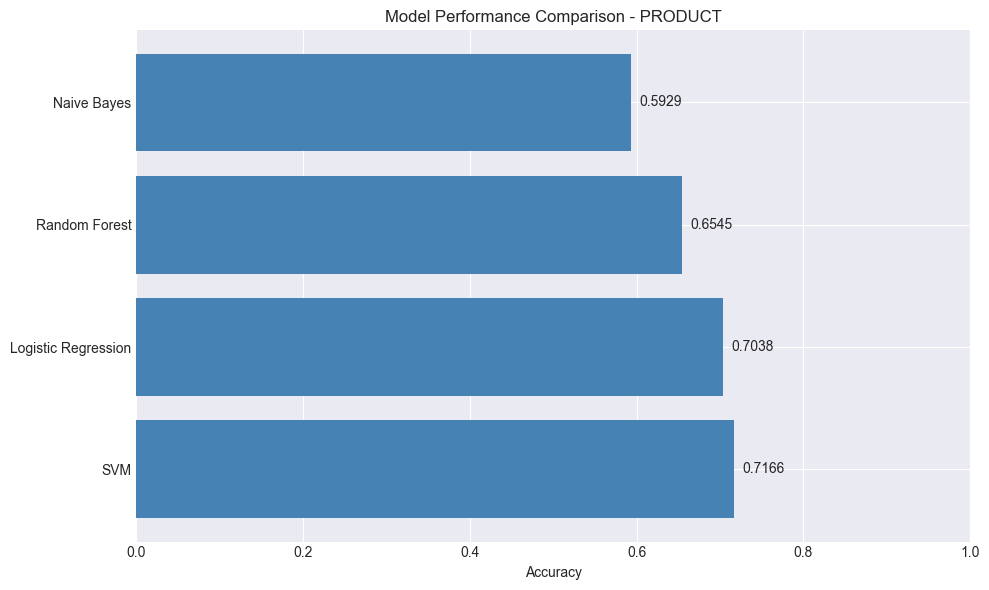


Results for: ISSUE

Model Performance:
              Model  Accuracy
                SVM  0.709561
Logistic Regression  0.691990
      Random Forest  0.648579
        Naive Bayes  0.512661


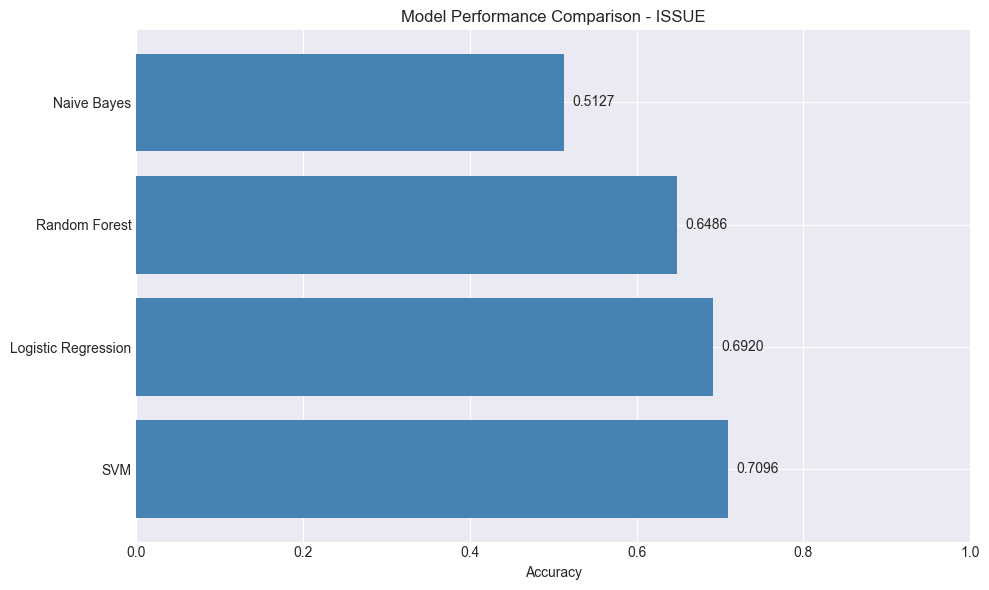

In [ ]:
# ============================================================================
# MODEL EVALUATION - COMPARISON
# ============================================================================
# Compare performance of all models for each target
# This helps identify which models work best for different classification tasks

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

for target_col in TARGET_COLUMNS:
    print(f"\n{'='*80}")
    print(f"RESULTS FOR: {target_col.upper()}")
    print(f"{'='*80}")
    
    results = all_results[target_col]['results']
    
    # Create comparison DataFrame
    model_comparison = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['accuracy'] for m in results.keys()]
    }).sort_values('Accuracy', ascending=False)
    
    print("\nModel Performance (sorted by accuracy):")
    print("-" * 80)
    for idx, row in model_comparison.iterrows():
        print(f"  {row['Model']:20s} {row['Accuracy']:.4f} ({row['Accuracy']*100:.2f}%)")
    
    # Visualize model comparison
    plt.figure(figsize=(10, 6))
    plt.barh(model_comparison['Model'], model_comparison['Accuracy'], color='steelblue')
    plt.xlabel('Accuracy', fontsize=12)
    plt.title(f'Model Performance Comparison - {target_col.upper()}', fontsize=14, fontweight='bold')
    plt.xlim([0, 1])
    
    # Add accuracy labels on bars
    for i, v in enumerate(model_comparison['Accuracy']):
        plt.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 7. Detailed Model Evaluation

Detailed evaluation metrics for the best models.


In [ ]:
# ============================================================================
# DETAILED MODEL EVALUATION
# ============================================================================
# Generate detailed classification reports for the best model of each target
# This provides precision, recall, and F1-score for each class

print("\n" + "="*80)
print("DETAILED MODEL EVALUATION")
print("="*80)

for target_col in TARGET_COLUMNS:
    print(f"\n{'='*80}")
    print(f"DETAILED EVALUATION FOR: {target_col.upper()}")
    print(f"{'='*80}")
    
    results = all_results[target_col]['results']
    label_encoder = all_results[target_col]['label_encoder']
    y_test = all_results[target_col]['y_test']
    
    # Find best model (highest accuracy)
    best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
    y_pred_best = results[best_model_name]['predictions']
    best_accuracy = results[best_model_name]['accuracy']
    
    print(f"\nBest Model: {best_model_name}")
    print(f"Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
    print("\n" + "-"*80)
    print("Classification Report (per class):")
    print("-"*80)
    print(classification_report(
        y_test, 
        y_pred_best, 
        target_names=label_encoder.classes_,
        digits=4
    ))



Detailed Evaluation for: PRODUCT

Best Model: SVM
Accuracy: 0.7166

Classification Report:
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.62      0.34      0.44       330
                                                 Checking or savings account       0.69      0.84      0.76       858
                                                               Consumer Loan       0.70      0.15      0.24        48
                                                                 Credit card       0.64      0.41      0.50       414
                                                 Credit card or prepaid card       0.68      0.83      0.75      1008
Credit reporting, credit repair services, or other personal consumer reports       0.73      0.72      0.72       418
                                                             Debt collection     

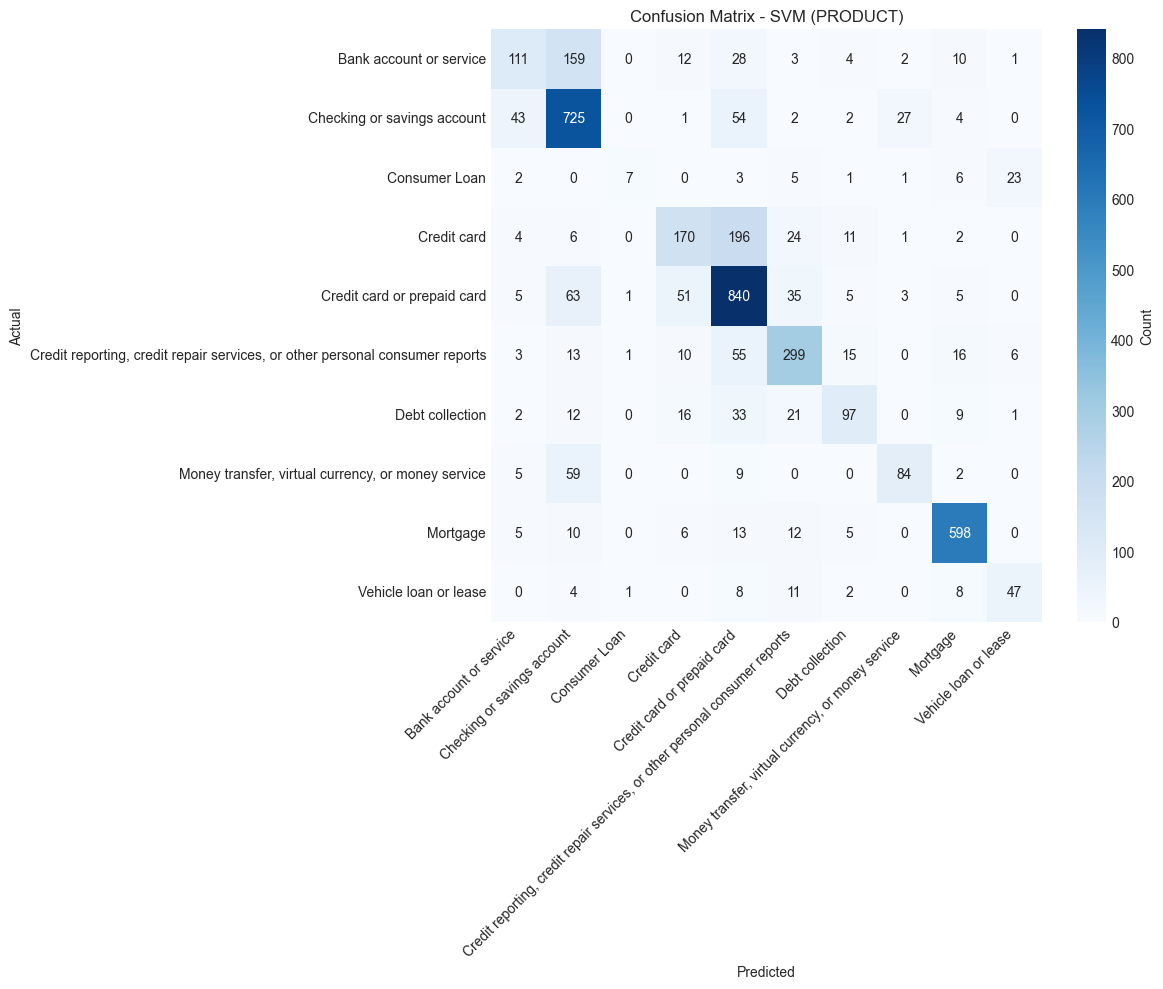

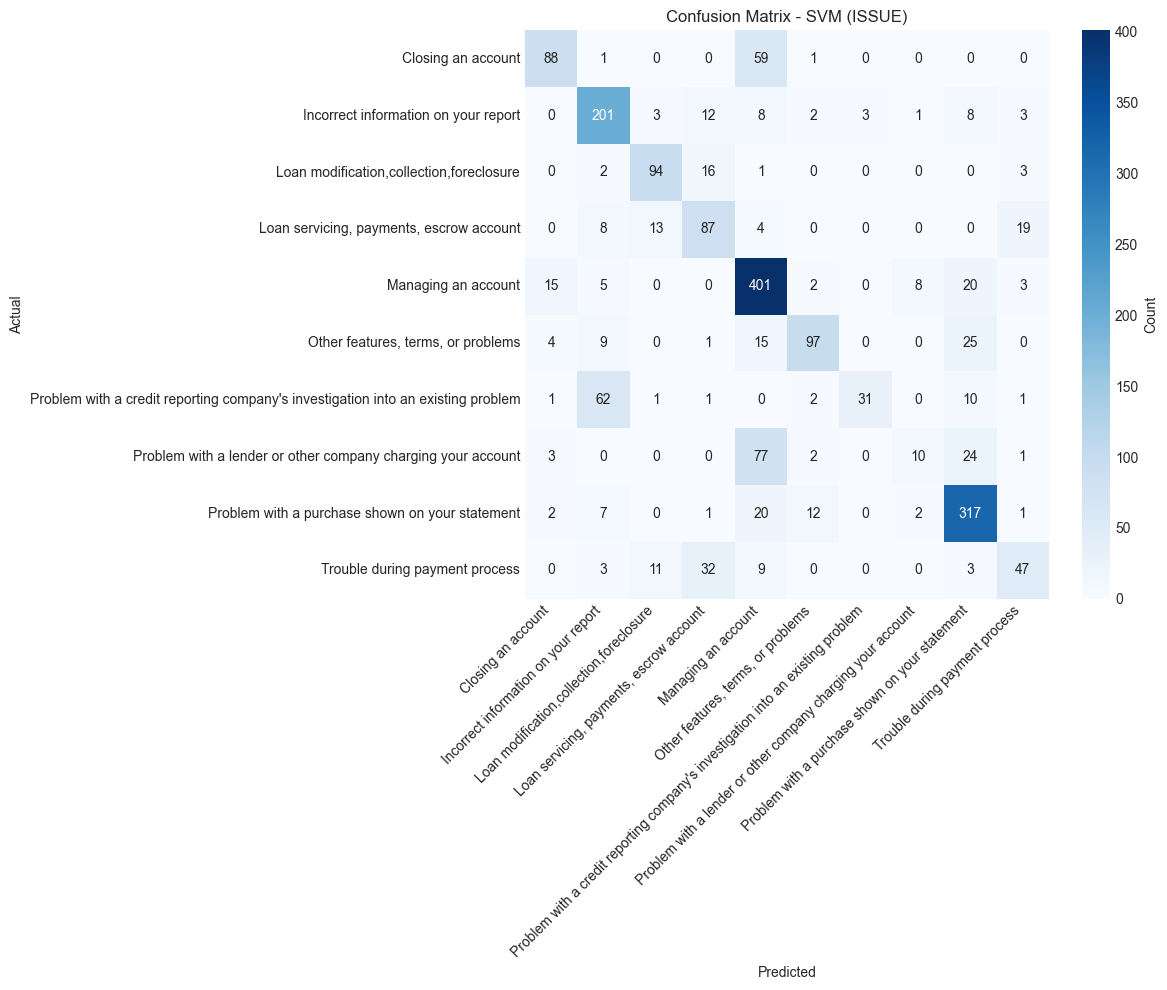

In [ ]:
# ============================================================================
# CONFUSION MATRICES
# ============================================================================
# Visualize confusion matrices for the best model of each target
# Confusion matrices show which classes are often confused with each other

print("\n" + "="*80)
print("CONFUSION MATRICES")
print("="*80)
print("Generating confusion matrices for best models...")

for target_col in TARGET_COLUMNS:
    results = all_results[target_col]['results']
    label_encoder = all_results[target_col]['label_encoder']
    y_test = all_results[target_col]['y_test']
    
    # Get best model predictions
    best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
    y_pred_best = results[best_model_name]['predictions']
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred_best)
    
    # Visualize
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm, 
        annot=True,           # Show numbers in cells
        fmt='d',              # Integer format
        cmap='Blues',         # Color scheme
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        cbar_kws={'label': 'Count'}
    )
    plt.title(
        f'Confusion Matrix - {best_model_name} ({target_col.upper()})',
        fontsize=14,
        fontweight='bold',
        pad=20
    )
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Confusion matrix generated for {target_col} ({best_model_name})")


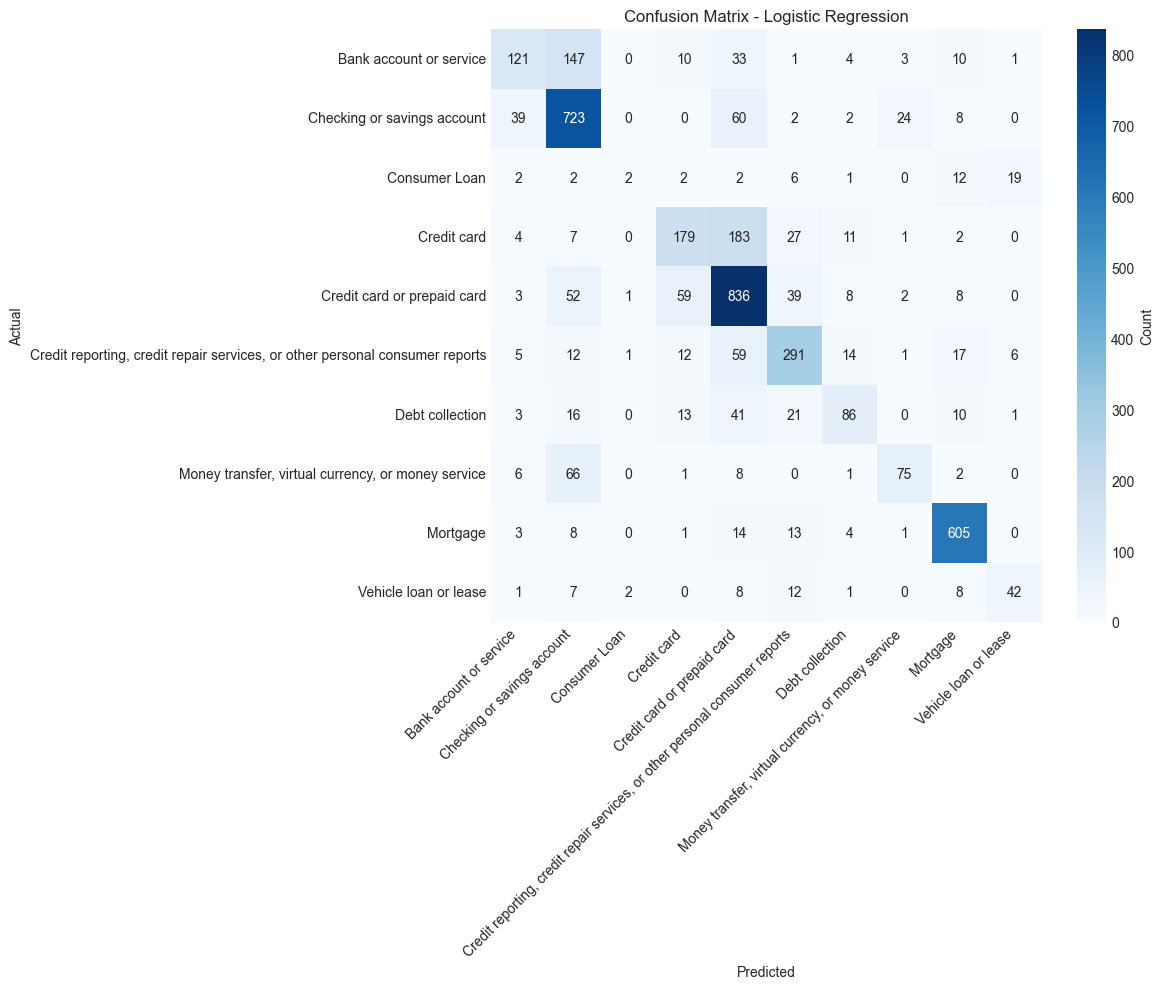

In [ ]:
## 8. Sample Predictions

Test the models with sample predictions from the test set to see how they perform on real examples.


## 9. Save Models

Save all trained models, vectorizers, and label encoders for deployment in the web interface.


In [ ]:
# ============================================================================
# SAMPLE PREDICTIONS
# ============================================================================
# Test models with sample complaints from the test set
# This demonstrates how the models perform on real examples

def predict_complaint(text, model, vectorizer, label_encoder):
    """
    Predict the category for a new complaint text using a trained model.
    
    Args:
        text: Complaint text string
        model: Trained sklearn model
        vectorizer: Fitted TF-IDF vectorizer
        label_encoder: Fitted label encoder
    
    Returns:
        prediction: Predicted class name
        confidence: Confidence score (probability) for the prediction
        prediction_proba: Probability distribution over all classes
    """
    # Preprocess text (same as training)
    text_processed = preprocess_text(text)
    
    # Convert text to TF-IDF vector
    text_vectorized = vectorizer.transform([text_processed])
    
    # Get prediction and probabilities
    prediction_encoded = model.predict(text_vectorized)[0]
    prediction_proba = model.predict_proba(text_vectorized)[0]
    
    # Decode prediction back to class name
    prediction = label_encoder.inverse_transform([prediction_encoded])[0]
    confidence = prediction_proba[prediction_encoded]
    
    return prediction, confidence, prediction_proba

# ============================================================================
# GENERATE SAMPLE PREDICTIONS
# ============================================================================
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)
print("Testing models with sample complaints from test set...")

for target_col in TARGET_COLUMNS:
    print(f"\n{'='*80}")
    print(f"SAMPLE PREDICTIONS FOR: {target_col.upper()}")
    print(f"{'='*80}")
    
    results = all_results[target_col]['results']
    vectorizer = all_results[target_col]['vectorizer']
    label_encoder = all_results[target_col]['label_encoder']
    y_test = all_results[target_col]['y_test']
    
    # Get best model
    best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
    best_model = results[best_model_name]['model']
    
    # Get test set text (we need to reconstruct the split to get original text)
    # We'll use the stored test indices if available, otherwise use a subset
    df_filtered = data_filtered[target_col]
    
    # Recreate the same split to get test text
    _, X_test_text, _, y_test_labels = train_test_split(
        df_filtered['text_processed'].values,
        label_encoder.transform(df_filtered[target_col].values),
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=label_encoder.transform(df_filtered[target_col].values)
    )
    
    # Show 3 sample predictions
    num_samples = min(3, len(X_test_text))
    print(f"\nShowing {num_samples} sample predictions using {best_model_name} model:")
    print("-" * 80)
    
    for i in range(num_samples):
        text = X_test_text[i]
        true_label_encoded = y_test_labels[i]
        true_label = label_encoder.inverse_transform([true_label_encoded])[0]
        
        # Get prediction
        pred_label, confidence, proba = predict_complaint(
            text, best_model, vectorizer, label_encoder
        )
        
        # Display results
        print(f"\n{'='*80}")
        print(f"Sample {i+1}:")
        print(f"{'='*80}")
        print(f"Text (first 250 chars):")
        print(f"  {text[:250]}...")
        print(f"\nTrue Label:     {true_label}")
        print(f"Predicted Label: {pred_label}")
        print(f"Confidence:      {confidence:.4f} ({confidence*100:.2f}%)")
        print(f"Correct:         {'✓' if true_label == pred_label else '✗'}")
        
        # Show top 3 predictions
        top_3_indices = proba.argsort()[-3:][::-1]
        print(f"\nTop 3 Predictions:")
        for rank, idx in enumerate(top_3_indices, 1):
            class_name = label_encoder.classes_[idx]
            prob = proba[idx]
            marker = "⭐" if rank == 1 else "  "
            print(f"  {marker} {rank}. {class_name[:70]:<70} {prob:.4f} ({prob*100:.2f}%)")


SAMPLE PREDICTIONS

Sample Predictions for: PRODUCT

Sample 1:
Text: I found fraudulent activity on my credit report in XXXX, 2015. I disputed the information with the XXXX credit bureaus and filed a fraud alert. I also called the XXXX creditors to report the fraud. ( ...
True Label: Credit card
Predicted Label: Credit reporting, credit repair services, or other personal consumer reports
Confidence: 0.6045
Top 3 Predictions:
  - Credit reporting, credit repair services, or other personal consumer reports: 0.6045
  - Credit card: 0.2801
  - Credit card or prepaid card: 0.0723

Sample 2:
Text: I just filed a complaint # XXXX on the wrong website for with the CFPB. IT was on Saturday XXXX/XXXX/16 and the chat was closed but I was angry about what Chase Bank was doing with my deposit. I depos...
True Label: Bank account or service
Predicted Label: Bank account or service
Confidence: 0.9762
Top 3 Predictions:
  - Bank account or service: 0.9762
  - Money transfer, virtual currency, or money

# Empty cell removed - notebook structure cleaned


In [ ]:
# ============================================================================
# SAVE MODELS FOR DEPLOYMENT
# ============================================================================
# Save all trained models, vectorizers, and label encoders to disk
# These files will be loaded by the web interface (app.py) for predictions

# Create models directory if it doesn't exist
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

print("\n" + "="*80)
print("SAVING ALL MODELS")
print("="*80)
print(f"Saving to directory: {models_dir}/")

for target_col in TARGET_COLUMNS:
    print(f"\n{'='*80}")
    print(f"SAVING MODELS FOR: {target_col.upper()}")
    print(f"{'='*80}")
    
    results = all_results[target_col]['results']
    vectorizer = all_results[target_col]['vectorizer']
    label_encoder = all_results[target_col]['label_encoder']
    
    # ========================================================================
    # SAVE ALL MODELS
    # ========================================================================
    print(f"\nSaving trained models...")
    for model_name, model_data in results.items():
        # Create filename: e.g., "product_naive_bayes_model.pkl"
        model_filename = f'{target_col}_{model_name.lower().replace(" ", "_")}_model.pkl'
        model_path = os.path.join(models_dir, model_filename)
        
        # Save model using pickle
        with open(model_path, 'wb') as f:
            pickle.dump(model_data['model'], f)
        
        print(f"  ✓ {model_name:20s} → {model_path}")
        print(f"      Accuracy: {model_data['accuracy']:.4f} ({model_data['accuracy']*100:.2f}%)")
    
    # ========================================================================
    # SAVE VECTORIZER AND LABEL ENCODER
    # ========================================================================
    # These are required for preprocessing new text and decoding predictions
    vectorizer_path = os.path.join(models_dir, f'{target_col}_tfidf_vectorizer.pkl')
    label_encoder_path = os.path.join(models_dir, f'{target_col}_label_encoder.pkl')
    
    with open(vectorizer_path, 'wb') as f:
        pickle.dump(vectorizer, f)
    print(f"\n  ✓ Vectorizer    → {vectorizer_path}")
    
    with open(label_encoder_path, 'wb') as f:
        pickle.dump(label_encoder, f)
    print(f"  ✓ Label Encoder → {label_encoder_path}")
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
    best_accuracy = results[best_model_name]['accuracy']
    
    print(f"\n  Summary:")
    print(f"    Best Model:      {best_model_name}")
    print(f"    Best Accuracy:   {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
    print(f"    Number of Classes: {len(label_encoder.classes_)}")
    print(f"    Total Models Saved: {len(results)}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("✓ ALL MODELS SAVED SUCCESSFULLY!")
print("="*80)

print("\nSaved Files Summary:")
print("-" * 80)
print("Product Classification Models:")
print("  • product_naive_bayes_model.pkl")
print("  • product_logistic_regression_model.pkl")
print("  • product_random_forest_model.pkl")
print("  • product_svm_model.pkl")
print("  • product_tfidf_vectorizer.pkl")
print("  • product_label_encoder.pkl")
print("\nIssue Classification Models:")
print("  • issue_naive_bayes_model.pkl")
print("  • issue_logistic_regression_model.pkl")
print("  • issue_random_forest_model.pkl")
print("  • issue_svm_model.pkl")
print("  • issue_tfidf_vectorizer.pkl")
print("  • issue_label_encoder.pkl")

print("\n" + "="*80)
print("💡 All models are now ready for the web interface!")
print("   Run 'python app.py' to start the Flask server.")
print("="*80)


SAVING ALL MODELS

Saving models for: PRODUCT

Saving models...
  ✓ Saved Naive Bayes (Accuracy: 0.5929)
  ✓ Saved Logistic Regression (Accuracy: 0.7038)
  ✓ Saved Random Forest (Accuracy: 0.6545)
  ✓ Saved SVM (Accuracy: 0.7166)
  ✓ Saved vectorizer: models/product_tfidf_vectorizer.pkl
  ✓ Saved label encoder: models/product_label_encoder.pkl

  Best Model: SVM (Accuracy: 0.7166)
  Number of Classes: 10

Saving models for: ISSUE

Saving models...
  ✓ Saved Naive Bayes (Accuracy: 0.5127)
  ✓ Saved Logistic Regression (Accuracy: 0.6920)
  ✓ Saved Random Forest (Accuracy: 0.6486)
  ✓ Saved SVM (Accuracy: 0.7096)
  ✓ Saved vectorizer: models/issue_tfidf_vectorizer.pkl
  ✓ Saved label encoder: models/issue_label_encoder.pkl

  Best Model: SVM (Accuracy: 0.7096)
  Number of Classes: 10

✓ ALL MODELS SAVED SUCCESSFULLY!

Saved files:
  Product models:
    - product_naive_bayes_model.pkl
    - product_logistic_regression_model.pkl
    - product_random_forest_model.pkl
    - product_svm_model.

## Summary

- **Dataset**: Consumer complaints with text narratives (78,313 records)
- **Targets Trained**: Both **product** and **issue** classification
- **Models Trained**: 4 models per target (Naive Bayes, Logistic Regression, Random Forest, SVM)
- **Classes**: Top 10 most frequent categories for each target
- **Total Models Saved**: 8 models + 2 vectorizers + 2 label encoders

### Models Available:
1. **Product Classification Models**: Classify complaints by product type
2. **Issue Classification Models**: Classify complaints by issue type

### Next Steps:
1. Use the saved models in the web interface for predictions
2. Try different text preprocessing techniques
3. Experiment with deep learning models (LSTM, BERT)
4. Fine-tune hyperparameters for better performance
5. Train models for sub_product and sub_issue if needed
